In [10]:

import jaxsp as jsp
import jax
jax.config.update("jax_enable_x64", True)
import numpy as np
import jax.numpy as jnp

import matplotlib.pyplot as plt

# Solution: need a minus sign infront of integral ext!!

In [27]:
def Integrate(r, f_at_lm, l_val, prefix):

    integrand_ext = r**(1-l_val) * f_at_lm
    integrand_int = r**(l_val + 2) * f_at_lm

    integrand_ext_rev = integrand_ext[::-1]
    r_rev = r[::-1]

    integral_ext_rev = np.zeros_like(r, dtype=complex)  # integral from r_max downwards

    integral_int = np.zeros_like(r, dtype=complex)  # integral from 0 to r
    
    for k in range(1, len(r)):
        dr_rev = r_rev[k] - r_rev[k - 1]
        integral_ext_rev[k] = integral_ext_rev[k - 1] + 0.5 * (integrand_ext_rev[k] + integrand_ext_rev[k - 1]) * dr_rev

        dr = r[k] - r[k - 1]
        integral_int[k] = integral_int[k - 1] + 0.5 * (integrand_int[k] + integrand_int[k - 1]) * dr

    integral_ext = -integral_ext_rev[::-1] #integral from r to r_max

    total_phi_lm = prefix * (r**(-(l_val + 1)) * integral_int + r**l_val * integral_ext)

    return total_phi_lm

In [28]:
l_val = 0
m_val = 0

m22 = 1
u = jsp.set_schroedinger_units(m22)

r_min = 0.01 * u.from_Kpc
r_max = 10 * u.from_Kpc

r = np.logspace(np.log10(r_min), np.log10(r_max), 1000)

f_at_lm = np.ones_like(r, dtype=complex)

prefix = -4 * np.pi / (2 * l_val + 1)

total_phi_lm = Integrate(r, f_at_lm, l_val, prefix)

print(total_phi_lm)

[-1.39072495+0.j -1.39072495+0.j -1.39072495+0.j -1.39072495+0.j
 -1.39072495+0.j -1.39072495+0.j -1.39072495+0.j -1.39072495+0.j
 -1.39072495+0.j -1.39072495+0.j -1.39072495+0.j -1.39072495+0.j
 -1.39072494+0.j -1.39072494+0.j -1.39072494+0.j -1.39072494+0.j
 -1.39072494+0.j -1.39072493+0.j -1.39072493+0.j -1.39072493+0.j
 -1.39072493+0.j -1.39072492+0.j -1.39072492+0.j -1.39072492+0.j
 -1.39072491+0.j -1.39072491+0.j -1.39072491+0.j -1.3907249 +0.j
 -1.3907249 +0.j -1.39072489+0.j -1.39072489+0.j -1.39072488+0.j
 -1.39072488+0.j -1.39072487+0.j -1.39072487+0.j -1.39072486+0.j
 -1.39072486+0.j -1.39072485+0.j -1.39072485+0.j -1.39072484+0.j
 -1.39072484+0.j -1.39072483+0.j -1.39072482+0.j -1.39072482+0.j
 -1.39072481+0.j -1.3907248 +0.j -1.39072479+0.j -1.39072479+0.j
 -1.39072478+0.j -1.39072477+0.j -1.39072476+0.j -1.39072475+0.j
 -1.39072475+0.j -1.39072474+0.j -1.39072473+0.j -1.39072472+0.j
 -1.39072471+0.j -1.3907247 +0.j -1.39072469+0.j -1.39072468+0.j
 -1.39072467+0.j -1.39072

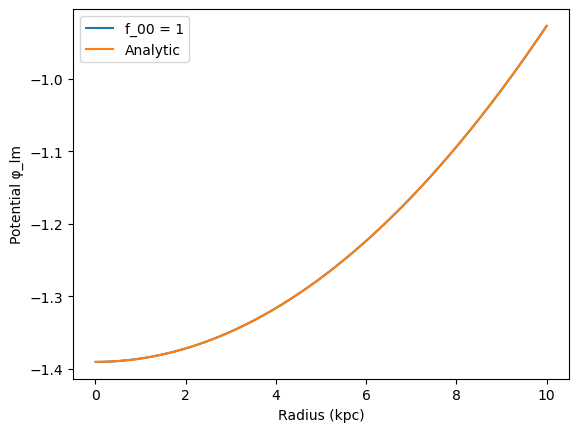

In [29]:
analytic = -4 * np.pi * (1/2 * r_max**2 - 1/6 * r**2 - 1/3 * r_min**3 / r)


plt.plot(r * u.to_Kpc, total_phi_lm, label='f_00 = 1')
plt.plot(r * u.to_Kpc, analytic, label='Analytic')
#plt.xscale('log')
#plt.yscale('log')
plt.xlabel('Radius (kpc)')
plt.ylabel('Potential φ_lm')
plt.legend()
plt.show()

# Why is it minus?!?!